In [14]:
import tensorflow as tf
import numpy as np
import pandas as pd
import re



In [15]:
df = pd.read_csv("/Users/maryamsaad/Documents/arabic_poetry_generator/datasets/poetry_generation_dataset.csv"
                 )
TEXT_COLUMN = "البيت"

In [ ]:
arabic_diacritics = re.compile(r"""
    ّ    | َ    | ً    | ُ    | ٌ    |
    ِ    | ٍ    | ْ    | ـ
""", re.VERBOSE)

def remove_diacritics(text):
    return arabic_diacritics.sub('', text)

def normalize_arabic(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)
    return text

def remove_non_arabic(text):
    return re.sub(r"[^ء-ي\s]", " ", text)

def clean_spaces(text):
    return re.sub(r"\s+", " ", text).strip()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = remove_diacritics(text)
    text = normalize_arabic(text)
    text = remove_non_arabic(text)
    text = clean_spaces(text)
    return text

print("Cleaning text...")
df["clean_text"] = df[TEXT_COLUMN].astype(str).apply(clean_text)

initial_count = len(df)
df = df[df["clean_text"].str.len() > 0].copy()
print(f"Removed {initial_count - len(df)} empty rows. Remaining rows: {len(df)}")

Cleaning text...
Removed 1 empty rows. Remaining rows: 777258
Removed 1 empty rows. Remaining rows: 777258


In [13]:
df

,Unnamed: 0,العصر,البيت,الشاعر,clean_text
0,0,عامي,الا واشيب عيني يوم قالوا لي فمان اله وتحقت ان...,عبدالله الفيصل,الا واشيب عيني يوم قالوا لي فمان اله وتحقت انه...
1,1,عامي,يا ابناء الارض انتشروا دقت اجراس الميلاد ضموا...,طلعت سقيرق,يا ابناء الارض انتشروا دقت اجراس الميلاد ضموا ...
2,2,عامي,فرسانا زين الشباب زين الشباب فرسانا نادي الوط...,طلعت سقيرق,فرسانا زين الشباب زين الشباب فرسانا نادي الوطن...
3,3,عامي,ارضي يا احلي من الهوي ومن لهفتو سكر المطر لما...,طلعت سقيرق,ارضي يا احلي من الهوي ومن لهفتو سكر المطر لما ...
4,4,عامي,فجرك طلع واله مع زهرك بلادي سيفك حجر واله وما...,طلعت سقيرق,فجرك طلع واله مع زهرك بلادي سيفك حجر واله وما ...
...,...,...,...,...,...
777254,777254,الحديث,هي أغلى ما أنشأ اللَّه في الدنيا وأحلى قصيد...,شهاب غانم,هي اغلي ما انشا الله في الدنيا واحلي قصيده تتغني
777255,777255,الحديث,هي أغرودة الأغاريد تنساب كحلم يغشى الجفون ا...,شهاب غانم,هي اغروده الاغاريد تنساب كحلم يغشي الجفون الوسني
777256,777256,الحديث,هي شلال بهجة وبهاء يتداعى وجداً ويخفق حسنا,شهاب غانم,هي شلال بهجه وبهاء يتداعي وجدا ويخفق حسنا
777257,777257,الحديث,هي حلم الهوى ومنطلقي الباقي يدك الحدود سجنا...,شهاب غانم,هي حلم الهوي ومنطلقي الباقي يدك الحدود سجنا فسجنا


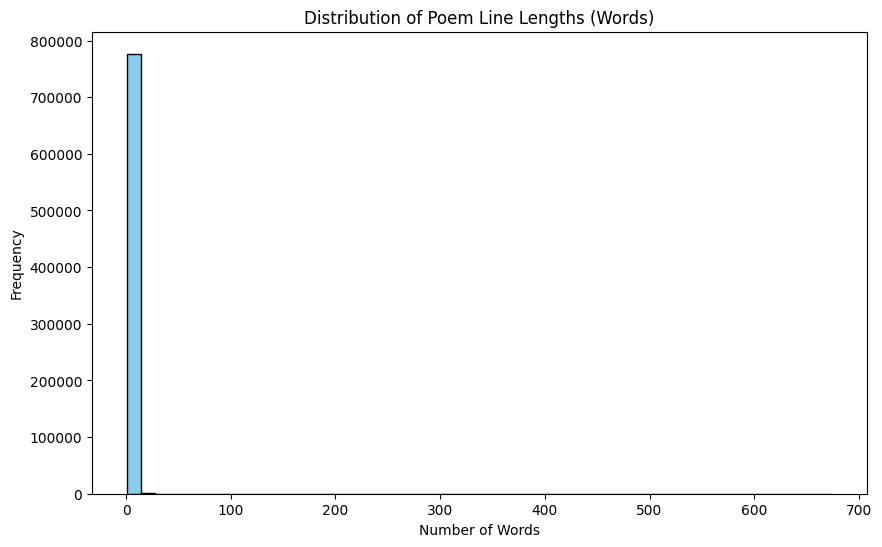

Average word count: 9.20
Max word count: 674


In [17]:
import matplotlib.pyplot as plt

# Calculate text lengths (number of words)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(df['word_count'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Poem Line Lengths (Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

print(f"Average word count: {df['word_count'].mean():.2f}")
print(f"Max word count: {df['word_count'].max()}")

In [18]:
# Validation: Check for any remaining non-Arabic characters
all_text = " ".join(df["clean_text"].astype(str))
unique_chars = set(all_text)
print(f"Unique characters in dataset: {len(unique_chars)}")
print(sorted(list(unique_chars)))

Unique characters in dataset: 30
[' ', 'ء', 'ا', 'ب', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ي']


In [19]:
# Save the cleaned dataset
output_path = "../datasets/cleaned_poetry_dataset.csv"
df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to {output_path}")

Cleaned dataset saved to ../datasets/cleaned_poetry_dataset.csv


Counting vocabulary...
Total words in dataset: 7,148,017
Vocabulary size (unique words): 417,490
Words appearing only once: 199,052 (47.7% of vocab)
Total words in dataset: 7,148,017
Vocabulary size (unique words): 417,490
Words appearing only once: 199,052 (47.7% of vocab)


/var/folders/c2/f9lh6rmd4q1648_pfl1636zw0000gn/T/ipykernel_65612/1430312528.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=words, y=counts, palette='viridis')


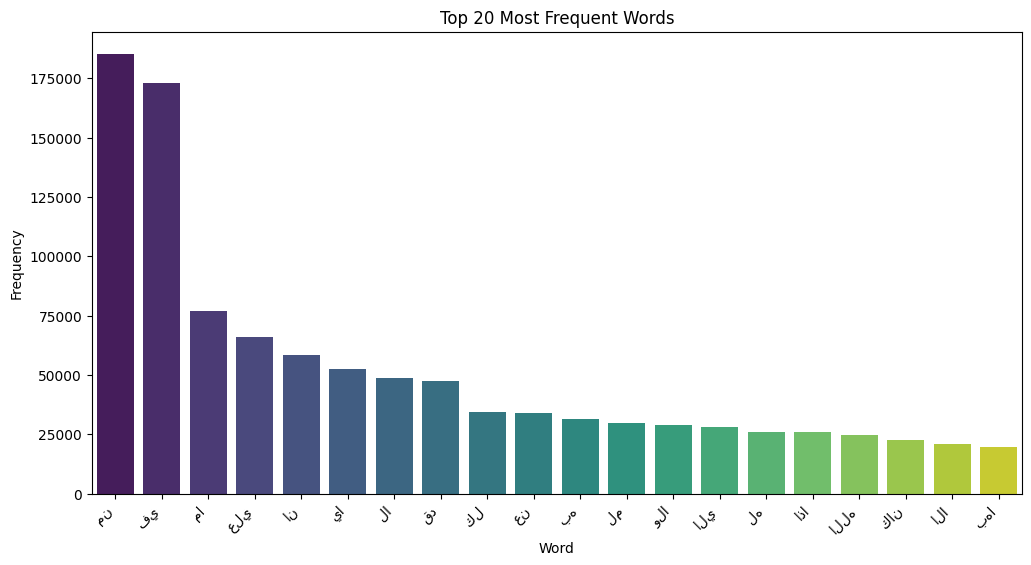

Analyzing Bigrams...


/var/folders/c2/f9lh6rmd4q1648_pfl1636zw0000gn/T/ipykernel_65612/1430312528.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(x_bigram), y=list(y_bigram), palette='magma')


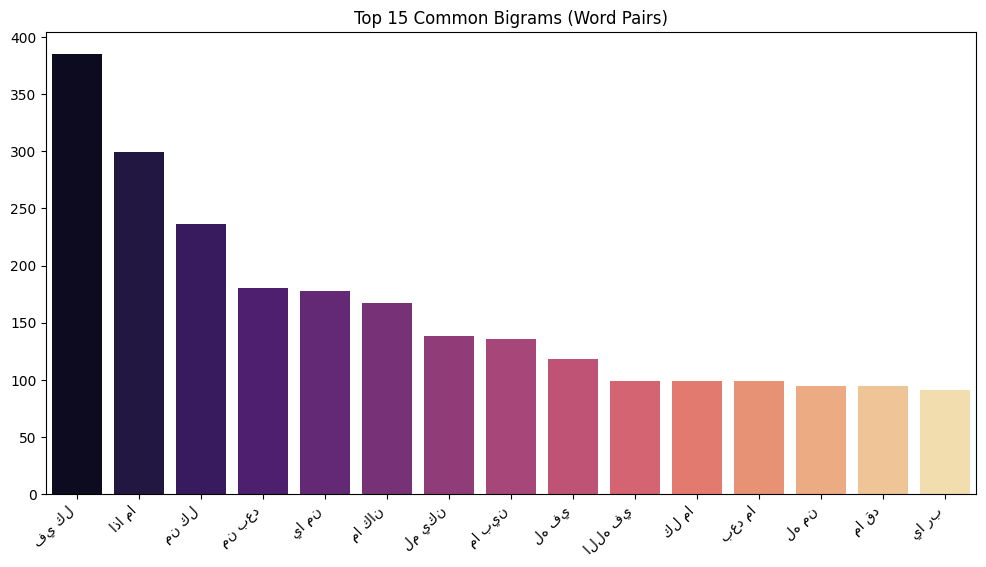

In [21]:
from collections import Counter
import seaborn as sns

# 1. Efficiently count words across the entire dataset
print("Counting vocabulary...")
word_counts = Counter()
df['clean_text'].str.split().apply(word_counts.update)

vocab_size = len(word_counts)
total_words = sum(word_counts.values())

print(f"Total words in dataset: {total_words:,}")
print(f"Vocabulary size (unique words): {vocab_size:,}")

# 2. Analyze Rare Words
# Words appearing only once (Hapax Legomena)
single_occurrence_words = sum(1 for count in word_counts.values() if count == 1)
print(f"Words appearing only once: {single_occurrence_words:,} ({single_occurrence_words/vocab_size:.1%} of vocab)")

# 3. Visualize Top 20 Frequent Words
top_words = word_counts.most_common(20)
words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(12, 6))
sns.barplot(x=words, y=counts, palette='viridis')
plt.title('Top 20 Most Frequent Words')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.show()

# 4. Bigram Analysis (Common Word Pairs)
from sklearn.feature_extraction.text import CountVectorizer

def get_top_bigrams(corpus, n=10):
    # Use a sample if dataset is too large for memory
    sample_size = min(50000, len(corpus))
    vec = CountVectorizer(ngram_range=(2, 2), max_features=2000).fit(corpus.sample(sample_size))
    bag_of_words = vec.transform(corpus.sample(sample_size))
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

print("Analyzing Bigrams...")
top_bigrams = get_top_bigrams(df['clean_text'], n=15)
x_bigram, y_bigram = zip(*top_bigrams)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(x_bigram), y=list(y_bigram), palette='magma')
plt.title('Top 15 Common Bigrams (Word Pairs)')
plt.xticks(rotation=45, ha='right')
plt.show()